<a href="https://colab.research.google.com/github/dewshishir/versity/blob/main/skillmorph2ndbatchzeroshotadvancedtechnique_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Computer Vision Class 2: Zero-Shot Learning with CLIP

**Complete Implementation with Bangladesh Vehicle Dataset**

**Instructor:** Md. Samiul Islam | **Skill Morph Research Lab**

---

## 📋 Notebook Contents:
1. Setup and Installation
2. Import Libraries
3. Load CLIP Model
4. Test CLIP (Basic Example)
5. Explore Your Vehicle Dataset
6. Standard vs Improved Prompts
7. Batch Processing
8. Accuracy Metrics


## 🔧 Step 1: Installation


In [ ]:
# STEP 1: Install libraries with FIXED versions
!pip install -q protobuf==3.20.3
!pip install -q transformers==4.30.2
!pip install -q torch torchvision pillow matplotlib

print("✅ Installation complete!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.3 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.1 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
google-api-core 2.30.0 requires protobuf<7.0.

## 📦 Step 2: Import Libraries

In [ ]:
# STEP 2: Import all required libraries
import torch
from PIL import Image
import requests
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO
import os
from collections import Counter
import time

print("✅ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ All imports successful!
PyTorch version: 2.10.0+cu128
CUDA available: True


## 🤖 Step 3: Load CLIP Model

In [ ]:
# STEP 3: Load CLIP model
print("Loading CLIP model (this may take 1-2 minutes)...")

model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print(f"\n✅ CLIP model loaded successfully on {device}!")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

Loading CLIP model (this may take 1-2 minutes)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ CLIP model loaded successfully on cuda!
Model parameters: 151.3M


## 🎨 Step 4: Define Helper Functions

In [ ]:
# Helper function to classify images
def classify_image(image_path, text_labels, show_image=True):
    """
    Classify an image using CLIP with given text labels.

    Args:
        image_path: Path to image or URL
        text_labels: List of text descriptions
        show_image: Whether to display the image

    Returns:
        Dictionary with probabilities for each label
    """
    # Load image
    if isinstance(image_path, str) and image_path.startswith('http'):
        response = requests.get(image_path)
        image = Image.open(BytesIO(response.content))
    else:
        image = Image.open(image_path)

    # Show image if requested
    if show_image:
        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"Image: {os.path.basename(str(image_path)) if not str(image_path).startswith('http') else 'Online Image'}")
        plt.show()

    # Process inputs
    inputs = processor(
        text=text_labels,
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(**inputs)
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1)

    # Create results dictionary
    results = {}
    for label, prob in zip(text_labels, probs[0]):
        results[label] = prob.item()

    # Sort by probability
    results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

    return results


def plot_predictions(results, title="Predictions"):
    """
    Plot prediction results as a horizontal bar chart.
    """
    labels = list(results.keys())
    probs = [results[label] * 100 for label in labels]

    plt.figure(figsize=(12, 6))
    bars = plt.barh(labels, probs, color=['#FF6B6B' if i == 0 else '#4ECDC4' for i in range(len(labels))])

    plt.xlabel('Confidence (%)', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlim(0, 100)

    # Add percentage labels
    for i, (label, prob) in enumerate(zip(labels, probs)):
        plt.text(prob + 1, i, f'{prob:.1f}%', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()


def batch_classify(image_paths, text_labels, show_progress=True):
    """
    Classify multiple images.
    """
    results_list = []

    for i, img_path in enumerate(image_paths):
        if show_progress:
            print(f"Processing {i+1}/{len(image_paths)}...", end='\r')

        results = classify_image(img_path, text_labels, show_image=False)

        # Get top prediction
        top_label = max(results, key=results.get)
        top_prob = results[top_label]

        results_list.append({
            'image': os.path.basename(img_path),
            'path': img_path,
            'prediction': top_label,
            'confidence': top_prob * 100,
            'all_scores': results
        })

    if show_progress:
        print("\n✅ Batch processing complete!")

    return results_list


print("✅ Helper functions defined!")

✅ Helper functions defined!


## 🧪 Step 5: Quick Test with Online Image

🔍 Testing CLIP with sample image...



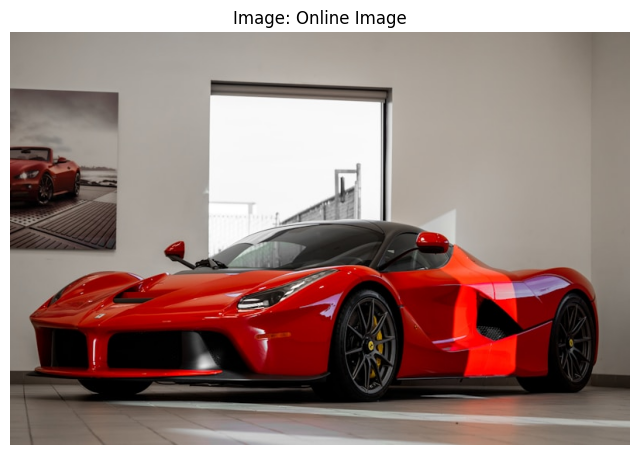


📊 Results:
  a photo of a car: 99.7%
  a photo of a cat: 0.2%
  a photo of a dog: 0.1%


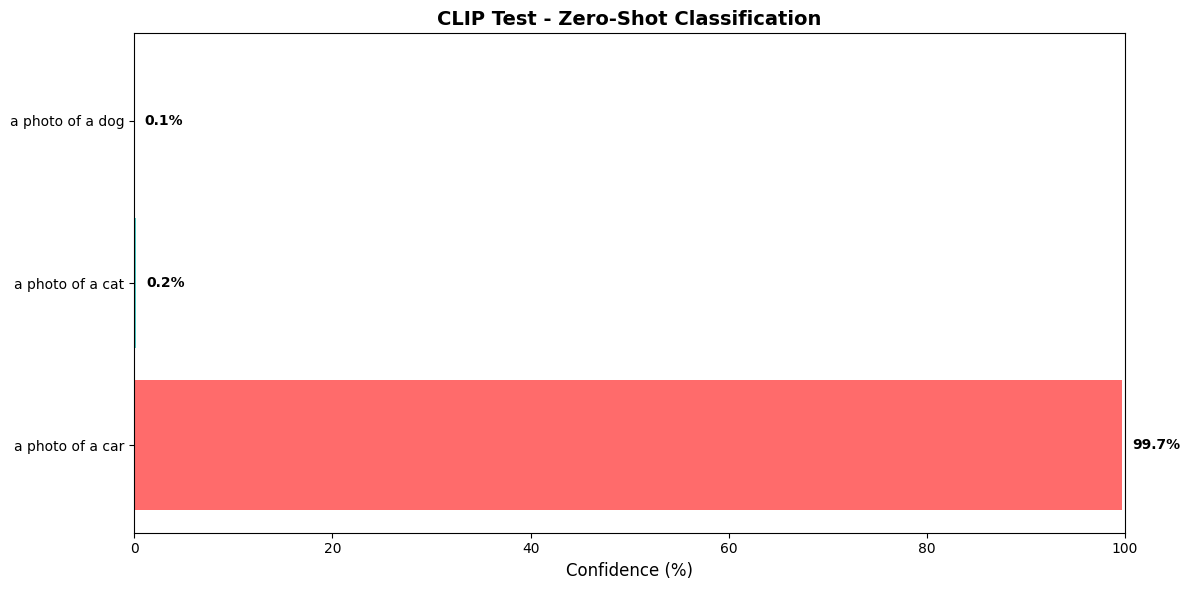


✅ CLIP is working perfectly!


In [ ]:
# Quick test to verify CLIP is working
print("🔍 Testing CLIP with sample image...\n")

test_url = "https://images.unsplash.com/photo-1583121274602-3e2820c69888?w=800"
test_labels = ["a photo of a cat", "a photo of a dog", "a photo of a car"]

results = classify_image(test_url, test_labels)

print("\n📊 Results:")
for label, prob in results.items():
    print(f"  {label}: {prob*100:.1f}%")

plot_predictions(results, "CLIP Test - Zero-Shot Classification")

print("\n✅ CLIP is working perfectly!")

---

## 🚗 WORKING WITH VEHICLE DATASET

---

## 📂 Step 6: Load Vehicle Dataset

In [ ]:
# Check dataset structure
dataset_path = '/kaggle/input/datasets/samiulcsedu/vechicle'

print("📂 Dataset Structure:")
print("="*60)

# Get image counts
train_dir = os.path.join(dataset_path, 'train/images')
valid_dir = os.path.join(dataset_path, 'valid/images')
test_dir = os.path.join(dataset_path, 'test/images')

train_images = [os.path.join(train_dir, f) for f in os.listdir(train_dir) if f.endswith(('.jpg', '.png'))]
valid_images = [os.path.join(valid_dir, f) for f in os.listdir(valid_dir) if f.endswith(('.jpg', '.png'))]
test_images = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png'))]

print(f"Train:      {len(train_images)} images")
print(f"Validation: {len(valid_images)} images")
print(f"Test:       {len(test_images)} images")
print(f"Total:      {len(train_images) + len(valid_images) + len(test_images)} images")
print("="*60)

print(f"\n✅ Dataset loaded from: {dataset_path}")
print(f"\nSample test images:")
for i, img in enumerate(test_images[:3]):
    print(f"  {i+1}. {os.path.basename(img)}")

📂 Dataset Structure:
Train:      82 images
Validation: 23 images
Test:       12 images
Total:      117 images

✅ Dataset loaded from: /kaggle/input/datasets/samiulcsedu/vechicle

Sample test images:
  1. car31_jpg.rf.b8f9e46c1f3b81bfeb732d819528bd3c.jpg
  2. download_jpg.rf.5c28b78938043c85cc3fe7229275607c.jpg
  3. Bus40_jpg.rf.a07a7e6eb44f4c724a7a8fe14ed40c9b.jpg


## 🏷️ Step 7: Define Label Sets

In [ ]:
# Standard labels (generic - like in the error you found)
standard_labels = [
    "a photo of a car",
    "a photo of a CNG auto-rickshaw",
    "a photo of a bus"
]

# Improved labels (more specific - should fix the bus/CNG confusion)
improved_labels = [
    "a photo of a private passenger car",
    "a photo of a small yellow three-wheeled CNG auto-rickshaw taxi",
    "a photo of a large public transport bus with many seats"
]

# Very detailed labels (maximum specificity)
detailed_labels = [
    "a four-wheeled private car for personal transportation",
    "a small three-wheeled motorized rickshaw taxi, also called CNG or auto-rickshaw",
    "a big multi-passenger public transportation bus, much larger than a car or rickshaw"
]

# Creative labels (zero-shot magic!)
creative_labels = [
    "an expensive luxury vehicle",
    "a budget-friendly local transport",
    "public transportation for many people",
    "a private vehicle for families",
    "a crowded vehicle",
    "commercial transport"
]

print("✅ Label sets defined!")
print(f"\nStandard labels: {len(standard_labels)}")
print(f"Improved labels: {len(improved_labels)}")
print(f"Detailed labels: {len(detailed_labels)}")
print(f"Creative labels: {len(creative_labels)}")

✅ Label sets defined!

Standard labels: 3
Improved labels: 3
Detailed labels: 3
Creative labels: 6


## 🔍 Step 8: Test on Single Image - Compare Prompts

TEST 1: Standard Labels (Generic)


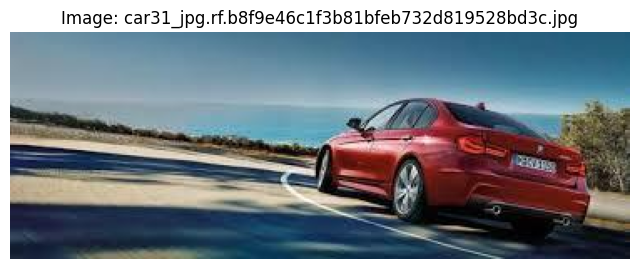


📊 Predictions:
  a photo of a car                                    99.9%
  a photo of a bus                                     0.1%
  a photo of a CNG auto-rickshaw                       0.0%

TEST 2: Improved Labels (More Specific)

📊 Predictions:
  a photo of a private passenger car                                     100.0%
  a photo of a large public transport bus with many seats                  0.0%
  a photo of a small yellow three-wheeled CNG auto-rickshaw taxi           0.0%

TEST 3: Creative Labels (Zero-Shot Magic!)

📊 Predictions:
  a private vehicle for families                      43.4%
  an expensive luxury vehicle                         43.0%
  commercial transport                                11.7%
  a crowded vehicle                                    1.4%
  a budget-friendly local transport                    0.4%
  public transportation for many people                0.1%

💡 Notice how different prompts give different results!


In [ ]:
# Test on first test image with different prompt styles
sample_img = test_images[0]

print("="*70)
print("TEST 1: Standard Labels (Generic)")
print("="*70)
results1 = classify_image(sample_img, standard_labels, show_image=True)
print("\n📊 Predictions:")
for label, prob in results1.items():
    print(f"  {label:50s} {prob*100:5.1f}%")

print("\n" + "="*70)
print("TEST 2: Improved Labels (More Specific)")
print("="*70)
results2 = classify_image(sample_img, improved_labels, show_image=False)
print("\n📊 Predictions:")
for label, prob in results2.items():
    print(f"  {label:70s} {prob*100:5.1f}%")

print("\n" + "="*70)
print("TEST 3: Creative Labels (Zero-Shot Magic!)")
print("="*70)
results3 = classify_image(sample_img, creative_labels, show_image=False)
print("\n📊 Predictions:")
for label, prob in results3.items():
    print(f"  {label:50s} {prob*100:5.1f}%")

print("\n💡 Notice how different prompts give different results!")

## 📊 Step 9: Batch Process ALL Test Images

In [ ]:
# Process all test images with STANDARD labels
print("🔍 Processing all test images with STANDARD labels...\n")
standard_results = batch_classify(test_images, standard_labels)

# Display results in table format
print("\n" + "="*90)
print(f"{'Image':<35s} {'Prediction':<35s} {'Confidence':>15s}")
print("="*90)

for result in standard_results:
    print(f"{result['image']:<35s} {result['prediction']:<35s} {result['confidence']:>14.1f}%")

print("="*90)

🔍 Processing all test images with STANDARD labels...

Processing 12/12...
✅ Batch processing complete!

Image                               Prediction                               Confidence
car31_jpg.rf.b8f9e46c1f3b81bfeb732d819528bd3c.jpg a photo of a car                              99.9%
download_jpg.rf.5c28b78938043c85cc3fe7229275607c.jpg a photo of a car                              48.2%
Bus40_jpg.rf.a07a7e6eb44f4c724a7a8fe14ed40c9b.jpg a photo of a CNG auto-rickshaw                81.3%
download_jpg.rf.fc36aaff1e6955e4e6869dad8c3477e5.jpg a photo of a CNG auto-rickshaw               100.0%
Bus48_jpg.rf.d24fe1e13128b2e521ba7f727e8a581d.jpg a photo of a CNG auto-rickshaw                94.1%
car40_jpg.rf.a37b8960934090e0b7ab36306c279c07.jpg a photo of a car                              99.6%
car20_jpg.rf.202a448c4f7511e0ea98fecbbb76a6c8.jpg a photo of a car                              98.7%
images_jpg.rf.cfed95b24fc237a1fa8c4aa51bdac055.jpg a photo of a car                     

In [ ]:
# Process all test images with IMPROVED labels
print("🔍 Processing all test images with IMPROVED labels...\n")
improved_results = batch_classify(test_images, improved_labels)

# Display results in table format
print("\n" + "="*110)
print(f"{'Image':<35s} {'Prediction':<60s} {'Confidence':>10s}")
print("="*110)

for result in improved_results:
    print(f"{result['image']:<35s} {result['prediction']:<60s} {result['confidence']:>9.1f}%")

print("="*110)

🔍 Processing all test images with IMPROVED labels...

Processing 12/12...
✅ Batch processing complete!

Image                               Prediction                                                   Confidence
car31_jpg.rf.b8f9e46c1f3b81bfeb732d819528bd3c.jpg a photo of a private passenger car                               100.0%
download_jpg.rf.5c28b78938043c85cc3fe7229275607c.jpg a photo of a large public transport bus with many seats           60.9%
Bus40_jpg.rf.a07a7e6eb44f4c724a7a8fe14ed40c9b.jpg a photo of a large public transport bus with many seats           97.7%
download_jpg.rf.fc36aaff1e6955e4e6869dad8c3477e5.jpg a photo of a small yellow three-wheeled CNG auto-rickshaw taxi      84.1%
Bus48_jpg.rf.d24fe1e13128b2e521ba7f727e8a581d.jpg a photo of a small yellow three-wheeled CNG auto-rickshaw taxi      58.0%
car40_jpg.rf.a37b8960934090e0b7ab36306c279c07.jpg a photo of a private passenger car                               100.0%
car20_jpg.rf.202a448c4f7511e0ea98fecbbb76a6c8.

## 📈 Step 11: Calculate Accuracy

In [ ]:
# STEP 11: Calculate Accuracy (FIXED VERSION)

# Calculate accuracy for both label sets
print("📊 Calculating Accuracy...\n")

std_correct = 0
imp_correct = 0
total = 0

confusion_std = {'car': {'car': 0, 'cng': 0, 'bus': 0},
                 'cng': {'car': 0, 'cng': 0, 'bus': 0},
                 'bus': {'car': 0, 'cng': 0, 'bus': 0}}

confusion_imp = {'car': {'car': 0, 'cng': 0, 'bus': 0},
                 'cng': {'car': 0, 'cng': 0, 'bus': 0},
                 'bus': {'car': 0, 'cng': 0, 'bus': 0}}

for std_result, imp_result in zip(standard_results, improved_results):
    ground_truth = get_ground_truth(std_result['image'])

    if ground_truth != 'unknown':
        total += 1

        # Standard prediction
        std_pred = 'car' if 'car' in std_result['prediction'].lower() else \
                   'cng' if 'cng' in std_result['prediction'].lower() else 'bus'

        # Improved prediction
        imp_pred = 'car' if 'car' in imp_result['prediction'].lower() else \
                   'cng' if 'cng' in imp_result['prediction'].lower() else 'bus'

        # Update confusion matrices
        confusion_std[ground_truth][std_pred] += 1
        confusion_imp[ground_truth][imp_pred] += 1

        # Count correct predictions
        if std_pred == ground_truth:
            std_correct += 1
        if imp_pred == ground_truth:
            imp_correct += 1

# Calculate accuracies
std_accuracy = (std_correct / total * 100) if total > 0 else 0
imp_accuracy = (imp_correct / total * 100) if total > 0 else 0

print("="*60)
print("ACCURACY COMPARISON")
print("="*60)
print(f"Standard Labels:  {std_correct}/{total} correct = {std_accuracy:.1f}%")
print(f"Improved Labels:  {imp_correct}/{total} correct = {imp_accuracy:.1f}%")
print(f"Improvement:      +{imp_accuracy - std_accuracy:.1f}%")
print("="*60)

# Print confusion matrix for standard labels
# FIX: Define header outside f-string to avoid backslash
header_label = "True/Pred"  # ✅ No backslash needed!
print("\n" + "="*60)
print("CONFUSION MATRIX - STANDARD LABELS")
print("="*60)
print(f"{header_label:<12s} {'car':>8s} {'cng':>8s} {'bus':>8s}")
print("-"*60)
for true_class in ['car', 'cng', 'bus']:
    print(f"{true_class:<12s}", end='')
    for pred_class in ['car', 'cng', 'bus']:
        count = confusion_std[true_class][pred_class]
        print(f"{count:>8d}", end='')
    print()
print("="*60)

# Print confusion matrix for improved labels
print("\n" + "="*60)
print("CONFUSION MATRIX - IMPROVED LABELS")
print("="*60)
print(f"{header_label:<12s} {'car':>8s} {'cng':>8s} {'bus':>8s}")
print("-"*60)
for true_class in ['car', 'cng', 'bus']:
    print(f"{true_class:<12s}", end='')
    for pred_class in ['car', 'cng', 'bus']:
        count = confusion_imp[true_class][pred_class]
        print(f"{count:>8d}", end='')
    print()
print("="*60)

📊 Calculating Accuracy...

ACCURACY COMPARISON
Standard Labels:  6/9 correct = 66.7%
Improved Labels:  8/9 correct = 88.9%
Improvement:      +22.2%

CONFUSION MATRIX - STANDARD LABELS
True/Pred         car      cng      bus
------------------------------------------------------------
car                5       1       0
cng                0       1       0
bus                0       2       0

CONFUSION MATRIX - IMPROVED LABELS
True/Pred         car      cng      bus
------------------------------------------------------------
car                6       0       0
cng                0       1       0
bus                0       1       1


## 🖼️ Step 13: Visualize Results

🖼️  Visualizing predictions on test images...



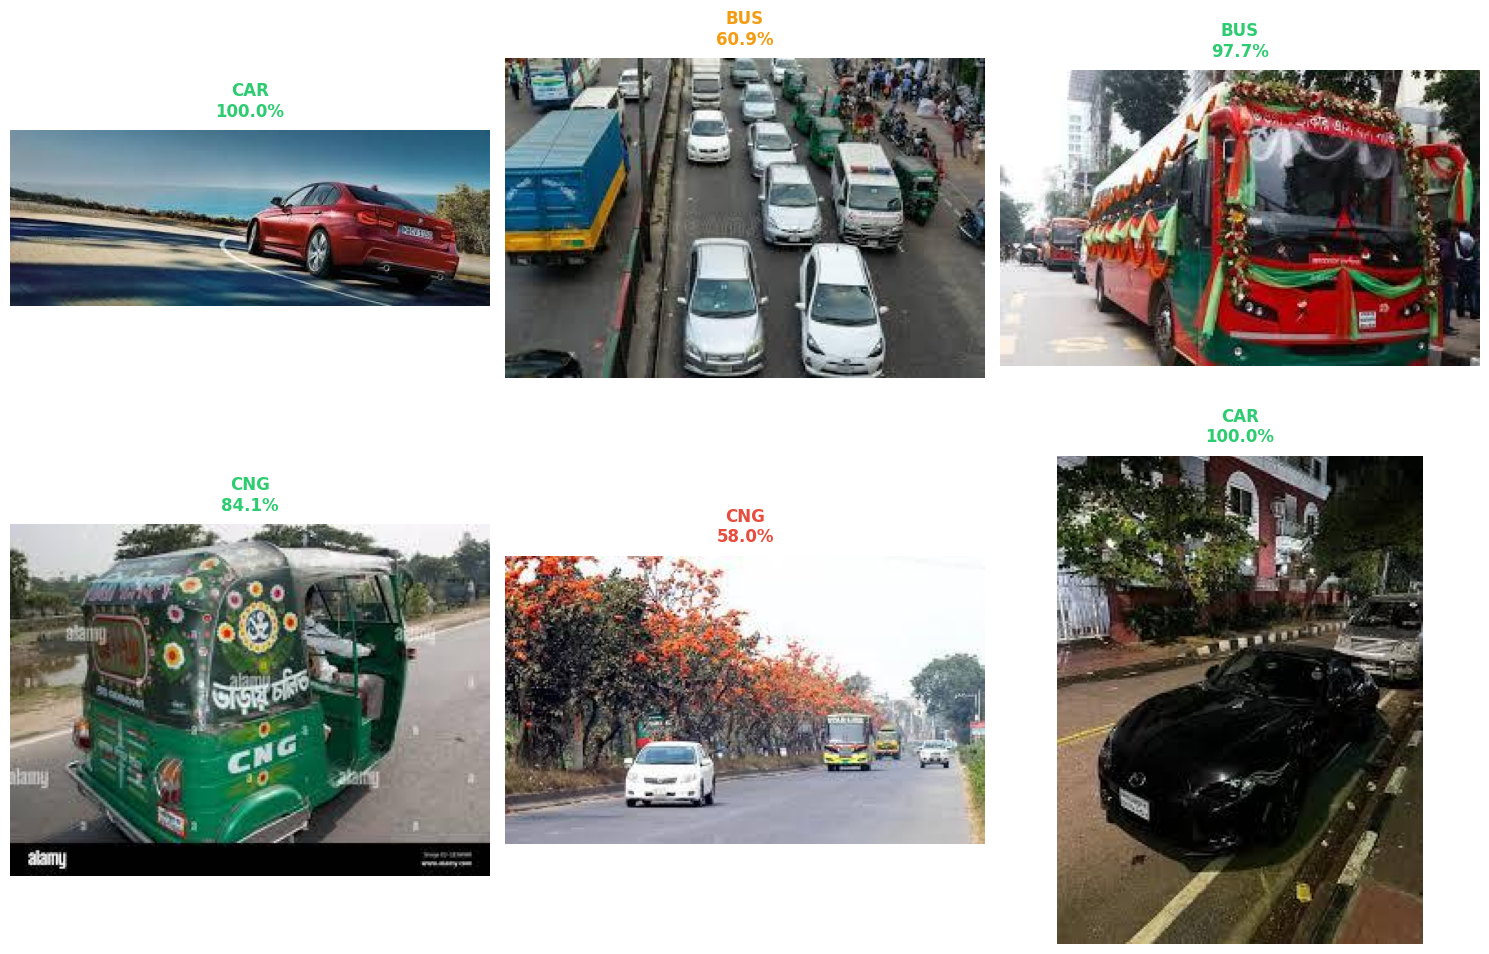

In [ ]:
# Visualize predictions on grid
def visualize_grid(image_paths, text_labels, num_images=6, cols=3):
    """
    Display multiple images with predictions in a grid.
    """
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = axes.flatten() if num_images > 1 else [axes]

    for i, (ax, img_path) in enumerate(zip(axes[:num_images], image_paths[:num_images])):
        # Load and display image
        image = Image.open(img_path)
        ax.imshow(image)
        ax.axis('off')

        # Get prediction
        results = classify_image(img_path, text_labels, show_image=False)
        top_label = max(results, key=results.get)
        confidence = results[top_label] * 100

        # Extract class name
        pred_class = 'CAR' if 'car' in top_label.lower() else \
                    'CNG' if 'cng' in top_label.lower() else 'BUS'

        # Color based on confidence
        color = '#2ECC71' if confidence > 80 else '#F39C12' if confidence > 60 else '#E74C3C'

        # Set title
        ax.set_title(f"{pred_class}\n{confidence:.1f}%",
                    fontsize=12, fontweight='bold', color=color, pad=10)

    # Hide extra subplots
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("🖼️  Visualizing predictions on test images...\n")
visualize_grid(test_images, improved_labels, num_images=6, cols=3)

---

## 🎯 Assignment Checklist

Use this notebook to complete your assignment:

### Part 1: Exploration
- ✅ Test CLIP on test images (done above)
- ✅ Try different category sets (standard, improved, creative)

### Part 2: Acccuracy
- ✅ Calculate CLIP accuracy (done above)
- ✅ Confusion matrices (generated above)
